In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
# --- Simulated automotive dataset (price as target) ---
n = 700
engine_size_L = np.random.uniform(1.0, 5.0, n)
horsepower = 60 + engine_size_L * 40 + np.random.normal(0, 15, n)
weight_kg = 900 + engine_size_L * 350 + np.random.normal(0, 100, n)
age_years = np.random.uniform(0, 15, n)
mileage_km = age_years * np.random.uniform(8000, 16000, n)
n_doors = np.random.choice([2, 4], n, p=[0.3, 0.7])
brand_score = np.random.uniform(0, 1, n)  # proxy for brand reputation/desirability

price = (25000 + horsepower * 80 - age_years * 1300 - mileage_km * 0.03
          + brand_score * 6000 + n_doors * 200 + np.random.normal(0, 1500, n))
price = np.clip(price, 2000, None)

In [ ]:
auto_df = pd.DataFrame({
    "engine_size_L": engine_size_L, "horsepower": horsepower, "weight_kg": weight_kg,
    "age_years": age_years, "mileage_km": mileage_km, "n_doors": n_doors,
    "brand_score": brand_score, "price": price
})
auto_df.head()

,engine_size_L,horsepower,weight_kg,age_years,mileage_km,n_doors,brand_score,price
0,2.498160,150.148877,1693.988710,7.133191,100688.735594,4,0.138125,25697.691327
1,4.802857,252.825269,2744.911710,8.145369,91858.324473,2,0.859112,38626.690653
2,3.927976,204.212830,2442.561600,3.416246,45235.845203,4,0.500058,38893.116643
3,3.394634,190.017024,2032.763054,14.460433,145788.532165,2,0.674893,21108.927575
4,1.624075,140.057375,1525.324405,13.641819,126540.670142,2,0.239066,17987.968015


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = auto_df.drop(columns=["price"])
y = auto_df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

preds = rf.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, preds):.2f} | R2: {r2_score(y_test, preds):.3f}")

MAE: 1595.83 | R2: 0.954


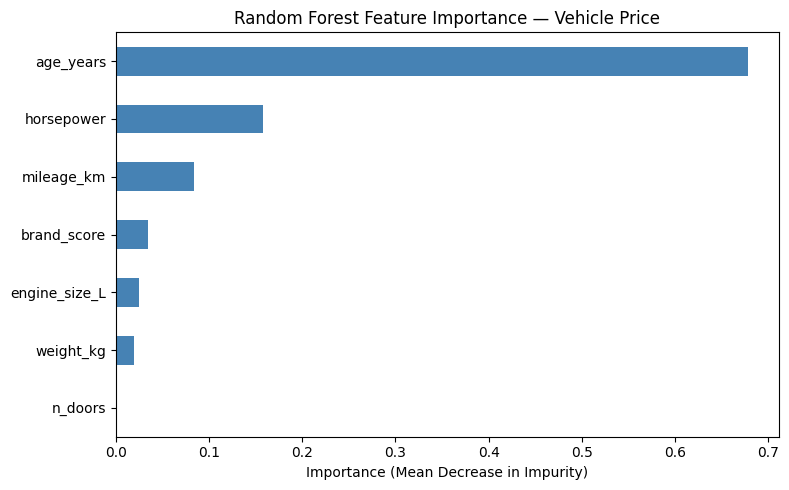

,0
age_years,0.677750
horsepower,0.157970
mileage_km,0.083568
brand_score,0.034842
engine_size_L,0.025015
weight_kg,0.019685
n_doors,0.001169


In [ ]:
# --- Built-in (impurity-based) feature importance ---
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Importance (Mean Decrease in Impurity)")
plt.title("Random Forest Feature Importance — Vehicle Price")
plt.tight_layout()
plt.show()

importances

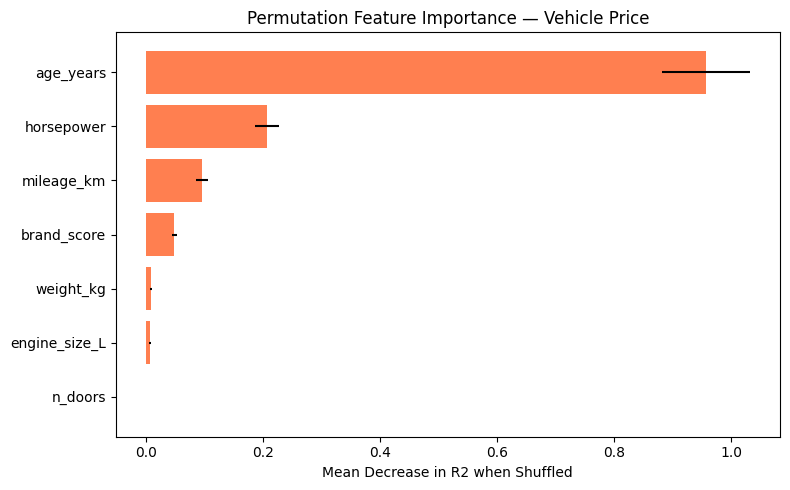

,0
age_years,0.955911
horsepower,0.206671
mileage_km,0.095705
brand_score,0.048617
weight_kg,0.008168
engine_size_L,0.006810
n_doors,0.000014


In [ ]:
from sklearn.inspection import permutation_importance

# --- Permutation importance (more robust, model-agnostic) ---
perm = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=42, n_jobs=-1)
perm_series = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(perm_series.index, perm_series.values, xerr=perm.importances_std[np.argsort(-perm.importances_mean)], color="coral")
plt.gca().invert_yaxis()
plt.xlabel("Mean Decrease in R2 when Shuffled")
plt.title("Permutation Feature Importance — Vehicle Price")
plt.tight_layout()
plt.show()

perm_series

/tmp/ipykernel_1761/2229078447.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


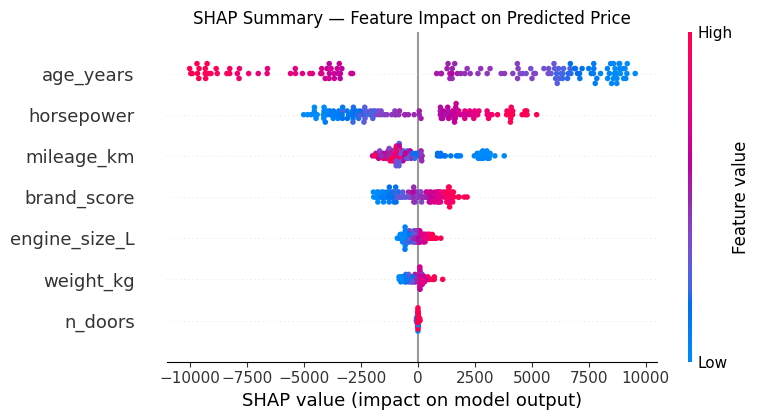

In [ ]:
import shap

# --- SHAP values for local + global interpretability ---
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary — Feature Impact on Predicted Price")
plt.tight_layout()
plt.show()